In [11]:
import numpy, pandas, sklearn, matplotlib
print("all good")

all good


Task 2: Python fundamental

In [12]:
# Declare Five Python data types

model_name = "iris-classifier" 
epochs = 10                     
accuracy = 0.98                  
is_trained = True                
missing_value = None             

print(model_name, type(model_name))
print(epochs, type(epochs))
print(accuracy, type(accuracy))
print(is_trained, type(is_trained))
print(missing_value, type(missing_value))

iris-classifier <class 'str'>
10 <class 'int'>
0.98 <class 'float'>
True <class 'bool'>
None <class 'NoneType'>


In [13]:
# Casting: convert a string to a float
mark = "95.8"
new_mark = float(mark)
print(new_mark)

95.8


In [14]:
# casting:  a float to an int
mark = 95.8
new_mark = int(mark)
print(new_mark) # when you convert float to interger will remove decimal doesn't round it. 

95


In [15]:
# An f-string  report

model_name = "iris-classifier"
accuracy = 0.98
epochs = 10

print(f"{model_name} reached {accuracy:.1%} accuracy in {epochs} epochs")

iris-classifier reached 98.0% accuracy in 10 epochs


In [16]:
# The condition checks both accuracy and latency before deciding whether to ship the model

accuracy = 0.98
threshold = 0.90
latency_ms = 240

if accuracy >= threshold and latency_ms < 300:
    decision = "ship it"
elif accuracy >= threshold:
    decision = "too slow"
else:
    decision = "keep training"

print(decision)

ship it


In [17]:
# four scores using enumerate() gives both the position and the score

scores = [0.71, 0.83, 0.88, 0.91]

for i, score in enumerate(scores, start=1):
    print(f"epoch {i}: {score:.2f}")

epoch 1: 0.71
epoch 2: 0.83
epoch 3: 0.88
epoch 4: 0.91


In [18]:
# List: ordered collection that can be changed
features = ["age", "income", "region"]

# Tuple: ordered collection that should not change
image_shape = (224, 224, 3)

# Dictionary: stores key-value pairs, useful for model configuration
config = {"model": "logreg", "C": 1.0}

# Set: stores unique values, useful when duplicates are not needed
seen_labels = {"cat", "dog", "cat","dog"}

print("List:", features)
print("Tuple:", image_shape)
print("Dictionary:", config)
print("Set:", seen_labels)

List: ['age', 'income', 'region']
Tuple: (224, 224, 3)
Dictionary: {'model': 'logreg', 'C': 1.0}
Set: {'dog', 'cat'}


In [19]:
# List comprehension with a filter: keeps only scores above 0.90
scores = [0.71, 0.83, 0.92, 0.98]

strong_scores = [score for score in scores if score > 0.90]

# Dictionary comprehension: creates model names and their scores
model_scores = {
    f"model_{i}": score
    for i, score in enumerate(scores)
}

print("Strong scores:", strong_scores)
print("Model scores:", model_scores)

Strong scores: [0.92, 0.98]
Model scores: {'model_0': 0.71, 'model_1': 0.83, 'model_2': 0.92, 'model_3': 0.98}


Task 3: Three Functions

In [20]:
def normalise(values, minimum=None, maximum=None):
    """
    Scale a list of numbers into the 0-1 range.

    Args:
        values: List of numbers to scale.
        minimum: Optional minimum bound.
        maximum: Optional maximum bound.

    Returns:
        A list of numbers scaled between 0 and 1.
    """
    if not values:
        return []

    lo = min(values) if minimum is None else minimum
    hi = max(values) if maximum is None else maximum

    # If all values are identical, avoid division by zero.
    if hi == lo:
        return [0.0 for _ in values]

    return [(value - lo) / (hi - lo) for value in values]


print(normalise([12, 18, 25, 40]))
print(normalise([5, 5, 5, 5]))

[0.0, 0.21428571428571427, 0.4642857142857143, 1.0]
[0.0, 0.0, 0.0, 0.0]


In [21]:
def summarise_scores(scores):
    """
    Summarise a list of scores.

    Args:
        scores: List of numeric scores.

    Returns:
        A dictionary containing count, mean, minimum, maximum,
        and the number of scores greater than or equal to 0.8.

        For an empty list, returns zeros and None for minimum
        and maximum.
    """
    if not scores:
        return {
            "count": 0,
            "mean": 0.0,
            "minimum": None,
            "maximum": None,
            "above_threshold": 0
        }

    return {
        "count": len(scores),
        "mean": sum(scores) / len(scores),
        "minimum": min(scores),
        "maximum": max(scores),
        "above_threshold": sum(score >= 0.8 for score in scores)
    }


print(summarise_scores([0.71, 0.83, 0.91, 0.78]))
print(summarise_scores([0.95, 0.88, 0.76]))
print(summarise_scores([]))

{'count': 4, 'mean': 0.8075, 'minimum': 0.71, 'maximum': 0.91, 'above_threshold': 2}
{'count': 3, 'mean': 0.8633333333333333, 'minimum': 0.76, 'maximum': 0.95, 'above_threshold': 2}
{'count': 0, 'mean': 0.0, 'minimum': None, 'maximum': None, 'above_threshold': 0}


In [22]:
def safe_divide(numerator, denominator, default=0.0):
    """
    Safely divide two numbers.

    Args:
        numerator: The number being divided.
        denominator: The number to divide by.
        default: Value returned when division cannot be performed.

    Returns:
        The division result, or default if the denominator is zero
        or either input is not numeric.
    """
    try:
        return numerator / denominator
    except (ZeroDivisionError, TypeError):
        return default


print("Normal:", safe_divide(10, 2))
print("Divide by zero:", safe_divide(10, 0))
print("Text input:", safe_divide("ten", 2))

Normal: 5.0
Divide by zero: 0.0
Text input: 0.0


Task 4: NumPy and Pandas

In [23]:
import numpy as np

# 1-D array with at least 6 numbers
scores_array = np.array([0.65, 0.72, 0.81, 0.88, 0.91, 0.95])

print("Mean:", scores_array.mean())
print("Standard deviation:", scores_array.std())
print("Minimum:", scores_array.min())
print("Maximum:", scores_array.max())

# 2-D array with shape (3, 4)
data_array = np.array([
    [10, 20, 30, 40],
    [15, 25, 35, 45],
    [20, 30, 40, 50]
])

print("Shape:", data_array.shape)
print("Transpose shape:", data_array.T.shape)

# Subtract column means using broadcasting
column_means = data_array.mean(axis=0)
centred_array = data_array - column_means

print("Column means:", column_means)
print("Centred array:")
print(centred_array)

Mean: 0.82
Standard deviation: 0.10614455552060438
Minimum: 0.65
Maximum: 0.95
Shape: (3, 4)
Transpose shape: (4, 3)
Column means: [15. 25. 35. 45.]
Centred array:
[[-5. -5. -5. -5.]
 [ 0.  0.  0.  0.]
 [ 5.  5.  5.  5.]]


In [24]:
import pandas as pd

df = pd.DataFrame({
    "candidate": ["Aline", "Bosco", "Chantal", "David", "Eric", "Fabrice"],
    "experience": [1, 4, 3, None, 2, 5],
    "score": [0.62, 0.91, 0.78, 0.55, 0.86, 0.73],
    "region": ["Kigali", "North", "South", "East", "Kigali", "West"]
})

print(df)

print("\nDataFrame information:")
df.info()

print("\nDescriptive statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isna().sum())

  candidate  experience  score  region
0     Aline         1.0   0.62  Kigali
1     Bosco         4.0   0.91   North
2   Chantal         3.0   0.78   South
3     David         NaN   0.55    East
4      Eric         2.0   0.86  Kigali
5   Fabrice         5.0   0.73    West

DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   candidate   6 non-null      str    
 1   experience  5 non-null      float64
 2   score       6 non-null      float64
 3   region      6 non-null      str    
dtypes: float64(2), str(2)
memory usage: 324.0 bytes

Descriptive statistics:
       experience     score
count    5.000000  6.000000
mean     3.000000  0.741667
std      1.581139  0.138191
min      1.000000  0.550000
25%      2.000000  0.647500
50%      3.000000  0.755000
75%      4.000000  0.840000
max      5.000000  0.910000

Missing values:
candidate     0
exper

In [25]:
# Filter candidates with scores of at least 0.75 and sort by score
filtered_df = df[df["score"] >= 0.75].sort_values("score", ascending=False)

print(filtered_df)

# Add a derived pass/fail column
df["passed"] = df["score"] >= 0.80

print("\nDataFrame with derived column:")
print(df)

  candidate  experience  score  region
1     Bosco         4.0   0.91   North
4      Eric         2.0   0.86  Kigali
2   Chantal         3.0   0.78   South

DataFrame with derived column:
  candidate  experience  score  region  passed
0     Aline         1.0   0.62  Kigali   False
1     Bosco         4.0   0.91   North    True
2   Chantal         3.0   0.78   South   False
3     David         NaN   0.55    East   False
4      Eric         2.0   0.86  Kigali    True
5   Fabrice         5.0   0.73    West   False


The missing experience value could mean that the candidate's experience was not recorded during data collection. In real data, I would investigate why the value is missing before deciding whether to remove the row or fill the value.

TASK 5 — One Chart, One Claim

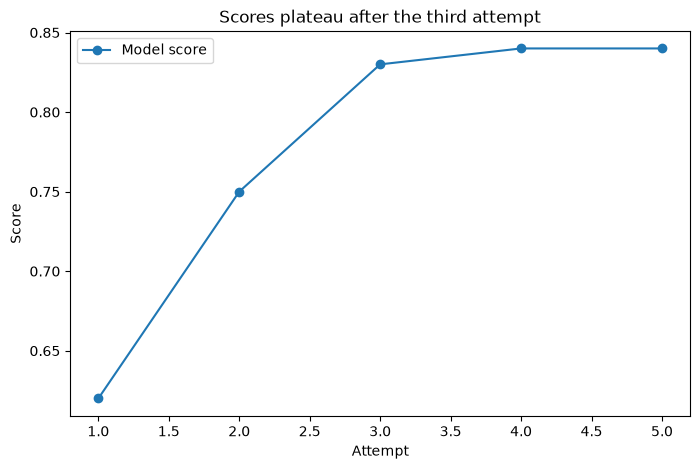

In [26]:
import matplotlib.pyplot as plt

attempts = [1, 2, 3, 4, 5]
scores = [0.62, 0.75, 0.83, 0.84, 0.84]

plt.figure(figsize=(8, 5))
plt.plot(attempts, scores, marker="o", label="Model score")

plt.xlabel("Attempt")
plt.ylabel("Score")
plt.title("Scores plateau after the third attempt")
plt.legend()
plt.show()